# Task 3 - Mini EDA on Titanic Dataset

In Task 3 I checked survival by gender and class. In this task I am doing a deeper EDA - handling missing values properly, using groupby to get more insights, and making more visualizations to tell a story about the data.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset

In [5]:

df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Cleaning the dataset

In [6]:
# checking missing values first
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
# fill missing Age values with mean age
df["Age"].fillna(df["Age"].mean(), inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_8728\2795481615.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [8]:
# drop Cabin column, too many missing values and not very useful
df.drop(columns=["Cabin"], inplace=True)

In [9]:
# there are 2 missing values in Embarked, fill with the most common port
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_8728\2048507419.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [10]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Creating new features for analysis

In [15]:
# Creating Age Group column
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Senior"]
)

# creating Family size column  (sibsp +Parch)
df["FamilySize"] = df["SibSp"] + df["Parch"]

df[["Age", "AgeGroup", "SibSp", "FamilySize"]].head()

,Age,AgeGroup,SibSp,FamilySize
0,22.0,YoungAdult,1,1
1,38.0,YoungAdult,1,1
2,26.0,YoungAdult,0,0
3,35.0,YoungAdult,1,1
4,35.0,YoungAdult,0,0


# 2. Analysis Questions

# Q1. Survival rate by Age Group

In [16]:
survival_by_agegroup = df.groupby("AgeGroup")["Survived"].mean()
print(survival_by_agegroup)

AgeGroup
Child         0.579710
Teen          0.428571
YoungAdult    0.363372
Senior        0.343750
Name: Survived, dtype: float64


C:\Users\Acer\AppData\Local\Temp\ipykernel_8728\150299858.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_agegroup = df.groupby("AgeGroup")["Survived"].mean()


Survival rate is highest for Children, and drops for other age groups. Seniors have the lowest survival rate among the group.

**Q2. Survival rate by Embarkation Port**

In [18]:
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()
print(survival_by_embarked)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


##  Q3. Survival rate by Family Size (SibSp + Parch)

In [19]:
survival_by_family = df.groupby("FamilySize")["Survived"].mean()
print(survival_by_family)

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


Passengers with small families (1 to 3 members) survived more compared to passengers travelling alone (FamilySize = 0) or with very large families.

# 3 Visulizations

1. Age  distribution (histogram)

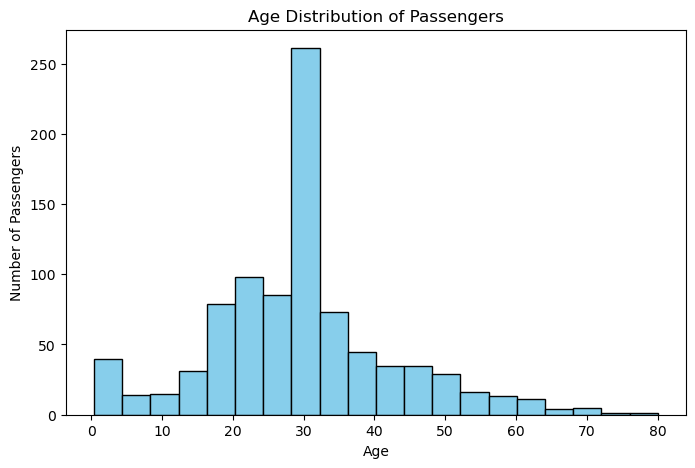

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

# Heatmap of correlations

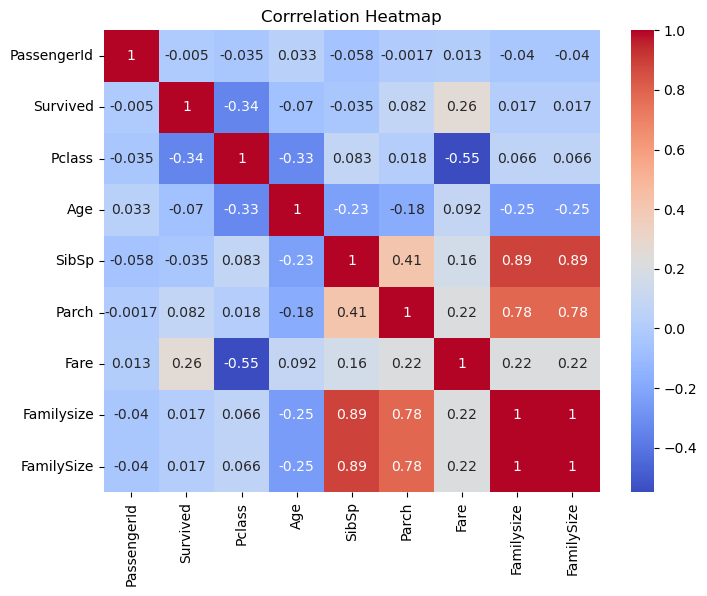

In [21]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Corrrelation Heatmap")
plt.show()

# Survival by Familay Size (bar plot)

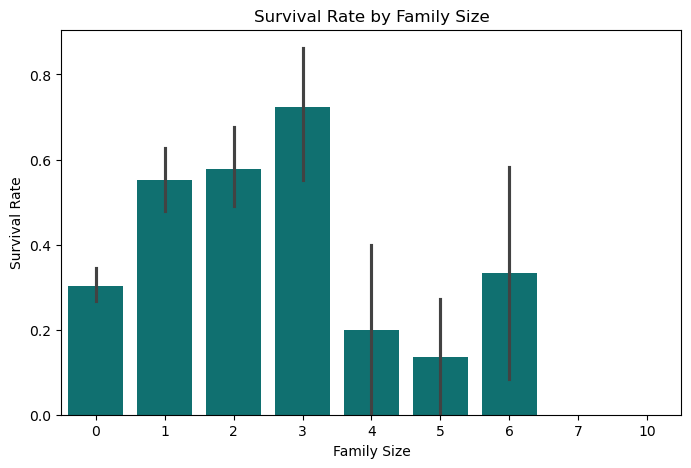

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(x="FamilySize", y="Survived", data=df, color="teal")
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

##   Key Insights
1. The dataset contained 891 passenger records.
2. Missing values were found mainly in Age, Cabin, and Embarked.
3. The Cabin column was removed because it contained too many missing values.
4. Missing values in the Age column were replaced with the mean age.
5. Female passengers had a higher survival rate than male passengers.
6. First-class passengers had the highest survival rate.
7. Children and young passengers had better survival chances than older passengers.
8. Passengers travelling with small families generally had better survival rates.
9. The embarkation port also influenced passenger survival.
10. Correlation analysis and visualizations helped identify relationships between different      features and survival.

## Conclusion

- Children had the highest survival rate compared to other age groups.
- Passengers who boarded from Cherbourg had better survival chances.
- Passengers with a small family (1-3 members) survived more than passengers travelling completely alone or with very large families.
- The correlation heatmap shows Fare and Pclass have a noticeable relationship with survival.